In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

csv_path = Path('k2_m7.csv')
if not csv_path.exists():
    csv_path = Path('DTW_Balls') / 'k2_m7.csv'

df = pd.read_csv(csv_path)
df.head()

,k,m,run_id,d_max,points_json,subset,witness_json,delta
0,2,7,1,9,"[[-2.8860632183908046, 0.921408045977012], [-2...",__POINTS__,NaN,NaN
1,2,7,1,9,NaN,1,"[-2.8860632183924366, -2.886063218393383, -2.8...",1.647916e-23
2,2,7,1,9,NaN,2,"[-2.5738904867268833, -2.5738106577550655, -2....",1.115317e-08
3,2,7,1,9,NaN,3,"[-2.1321496203249346, -2.132218162601739, -2.1...",8.226848e-09
4,2,7,1,9,NaN,4,"[-1.3631373600521504, -1.3630120671656076, -1....",1.962366e-08


In [3]:
points_row = df.loc[df['subset'] == '__POINTS__'].iloc[0]
points = np.array(json.loads(points_row['points_json']), dtype=float)
n_points = len(points)

subset_rows = df.loc[df['subset'].notna() & (df['subset'] != '__POINTS__')].copy()
subset_rows['subset_key'] = subset_rows['subset'].astype(str).str.replace(' ', '', regex=False)
subset_rows['subset_indices'] = subset_rows['subset_key'].map(lambda s: tuple(int(x) for x in s.split(',') if x))
subset_rows['witness'] = subset_rows['witness_json'].map(lambda s: np.array(json.loads(s), dtype=float))
subset_rows = subset_rows.set_index('subset_key').sort_index()

points_df = pd.DataFrame(points, columns=['x', 'y'], index=np.arange(1, n_points + 1))
points_df.index.name = 'i'
points_df

,x,y
i,,
1,-2.886063,0.921408
2,-2.573851,1.591523
3,-2.132184,2.170259
4,-1.363075,2.535776
5,1.781897,-3.053592
6,2.383477,-2.809914
7,2.680460,-2.170259
8,3.068822,-1.698132
9,-0.708190,2.695690


## DTW helper functions

The implementation below uses the standard dynamic-programming recursion with squared local cost $(a-b)^2$ and no final square root. This convention matches the scale of the radii stored in the CSV. If your DTW convention differs, adjust `dtw_distance()` accordingly.

In [4]:
def dtw_distance(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    dp = np.full((len(p) + 1, len(q) + 1), np.inf)
    dp[0, 0] = 0.0

    for i in range(1, len(p) + 1):
        for j in range(1, len(q) + 1):
            cost = (p[i - 1] - q[j - 1]) ** 2
            dp[i, j] = cost + min(
                dp[i - 1, j],
                dp[i, j - 1],
                dp[i - 1, j - 1],
            )

    return float(dp[-1, -1])


def membership_mask(indices, n=n_points):
    mask = np.zeros(n, dtype=bool)
    for idx in indices:
        mask[idx - 1] = True
    return mask


def distances_to_points(witness):
    return np.array([dtw_distance(witness, q) for q in points], dtype=float)


def analyze_subset(subset_key):
    row = subset_rows.loc[subset_key]
    witness = row['witness']
    indices = row['subset_indices']
    mask = membership_mask(indices)
    distances = distances_to_points(witness)
    delta = float(row['delta'])

    inside_max = float(distances[mask].max()) if mask.any() else np.nan
    outside_min = float(distances[~mask].min()) if (~mask).any() else np.nan

    detail = pd.DataFrame(
        {
            'x': points[:, 0],
            'y': points[:, 1],
            'dtw_distance': distances,
            'in_subset': mask,
            'inside_ball': distances <= delta + 1e-9,
        },
        index=[f'Q_{i}' for i in range(1, n_points + 1)],
    ).sort_values('dtw_distance')

    summary = {
        'subset': subset_key,
        'delta': delta,
        'inside_max': inside_max,
        'outside_min': outside_min,
        'margin': outside_min - inside_max,
        'delta_minus_inside_max': delta - inside_max,
        'outside_min_minus_delta': outside_min - delta,
    }
    return summary, detail


def evaluate_dtw_ball(witness, xlim=None, ylim=None, grid_size=180):
    if xlim is None:
        x_margin = 0.5
        xlim = (points[:, 0].min() - x_margin, points[:, 0].max() + x_margin)
    if ylim is None:
        y_margin = 0.5
        ylim = (points[:, 1].min() - y_margin, points[:, 1].max() + y_margin)

    xs = np.linspace(*xlim, grid_size)
    ys = np.linspace(*ylim, grid_size)
    z = np.empty((grid_size, grid_size), dtype=float)

    for iy, y in enumerate(ys):
        for ix, x in enumerate(xs):
            z[iy, ix] = dtw_distance(witness, np.array([x, y], dtype=float))

    return xs, ys, z


def plot_subset_ball(subset_key, ax=None, grid_size=180):
    row = subset_rows.loc[subset_key]
    witness = row['witness']
    indices = row['subset_indices']
    delta = float(row['delta'])
    mask = membership_mask(indices)

    xs, ys, z = evaluate_dtw_ball(witness, grid_size=grid_size)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    inside_region = (z <= delta).astype(float)
    ax.contourf(xs, ys, inside_region, levels=[-0.5, 0.5, 1.5], colors=['white', '#8ecae6'], alpha=0.35)
    ax.contour(xs, ys, z, levels=[delta], colors=['#1d3557'], linewidths=2)

    ax.scatter(points[~mask, 0], points[~mask, 1], color='#d62828', s=60, label='outside subset', zorder=3)
    ax.scatter(points[mask, 0], points[mask, 1], color='#2a9d8f', s=80, label='inside subset', zorder=4)

    for i, (x, y) in enumerate(points, start=1):
        ax.text(x + 0.05, y + 0.05, f'Q_{i}', fontsize=10)

    ax.set_title(f'Subset {{{subset_key}}} | Δ = {delta:.6f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')
    ax.legend(loc='best')
    return ax

In [5]:
example_subset = '2,8'
example_summary, example_detail = analyze_subset(example_subset)

pd.DataFrame([example_summary]).round(6)

,subset,delta,inside_max,outside_min,margin,delta_minus_inside_max,outside_min_minus_delta
0,"2,8",14.160567,14.160567,14.160667,0.0001,0.0,0.0001


In [6]:
example_detail.round(6)

,x,y,dtw_distance,in_subset,inside_ball
Q_8,3.068822,-1.698132,14.160567,True,True
Q_2,-2.573851,1.591523,14.160567,True,True
Q_1,-2.886063,0.921408,14.160667,False,False
Q_4,-1.363075,2.535776,14.160667,False,False
Q_7,2.680460,-2.170259,15.037456,False,False
Q_3,-2.132184,2.170259,15.415170,False,False
Q_9,-0.708190,2.695690,17.593991,False,False
Q_6,2.383477,-2.809914,21.869785,False,False
Q_5,1.781897,-3.053592,24.137736,False,False


## Plot selected subsets

Edit `subsets_to_plot` to visualize any subsets that appear in the CSV.

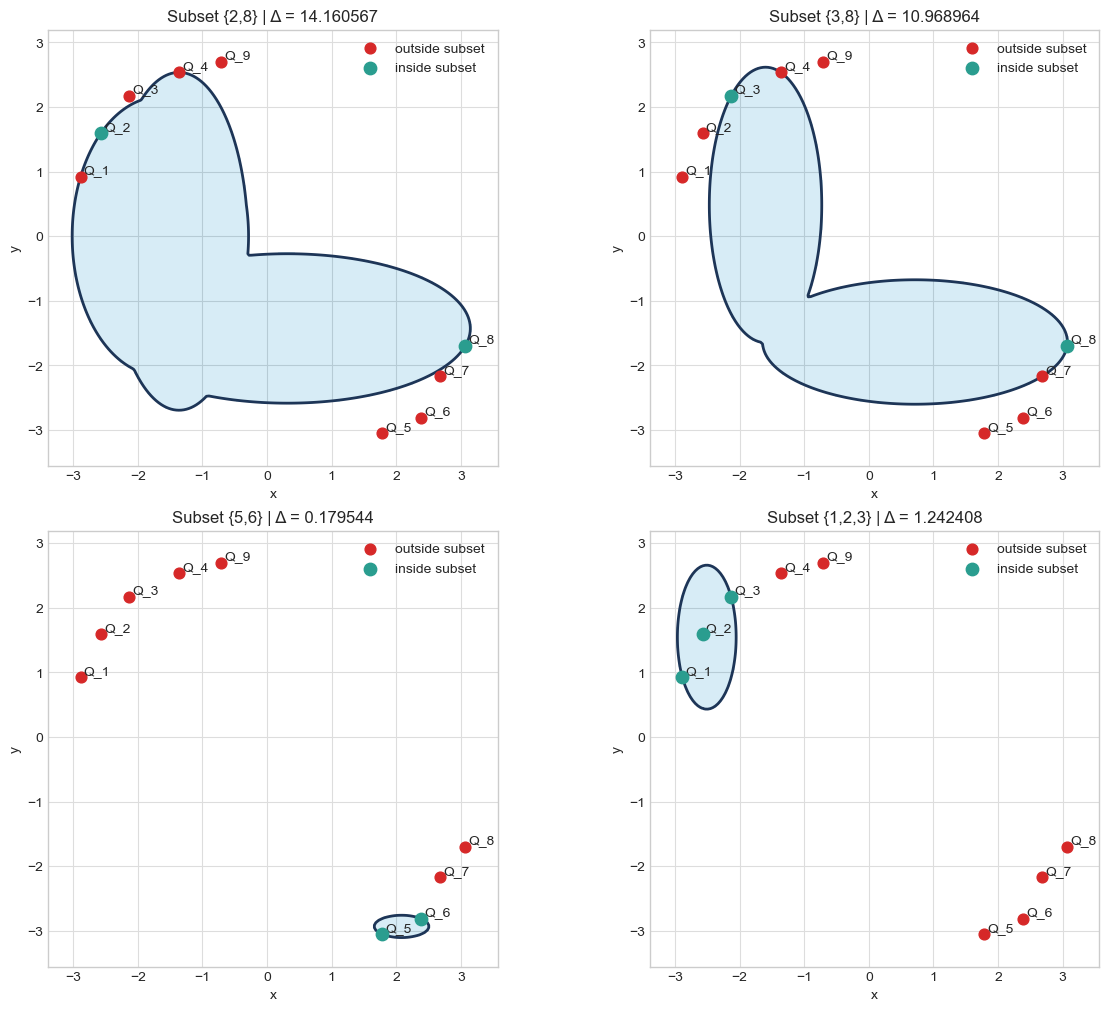

,delta,inside_max,outside_min,margin,delta_minus_inside_max,outside_min_minus_delta
subset,,,,,,
"2,8",14.160567,14.160567,14.160667,0.000100,0.0,0.000100
"3,8",10.968964,10.968964,10.969064,0.000100,-0.0,0.000100
"5,6",0.179544,0.179544,3.836609,3.657064,-0.0,3.657064
"1,2,3",1.242408,1.242408,8.860554,7.618146,0.0,7.618146


In [7]:
subsets_to_plot = ['2,8', '3,8', '5,6', '1,2,3']

ncols = 2
nrows = int(np.ceil(len(subsets_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

summary_rows = []
for ax, subset_key in zip(axes, subsets_to_plot):
    plot_subset_ball(subset_key, ax=ax, grid_size=180)
    summary, _ = analyze_subset(subset_key)
    summary_rows.append(summary)

for ax in axes[len(subsets_to_plot):]:
    ax.axis('off')

plt.show()
pd.DataFrame(summary_rows).set_index('subset').round(6)

In [8]:
all_summaries = []
for subset_key in subset_rows.index:
    summary, _ = analyze_subset(subset_key)
    all_summaries.append(summary)

all_summaries_df = pd.DataFrame(all_summaries).sort_values(['margin', 'subset'], ascending=[False, True])
all_summaries_df.head(15).round(6)

,subset,delta,inside_max,outside_min,margin,delta_minus_inside_max,outside_min_minus_delta
34,"1,2,3,4,9",5.784775,5.784775,39.259250,33.474475,0.0,33.474475
483,"5,6,7,8",2.943587,2.943587,35.915753,32.972166,0.0,32.972166
3,"1,2,3,4",4.130807,4.130807,12.969392,8.838584,0.0,8.838584
289,"2,3,4,9",2.698950,2.698950,10.514268,7.815318,0.0,7.815318
2,"1,2,3",1.242408,1.242408,8.860554,7.618146,0.0,7.618146
208,"1,4,5,8,9",21.548248,21.548248,28.910696,7.362448,0.0,7.362448
263,"2,3,4,5,6,7,8,9",13.393411,13.393411,20.692278,7.298868,-0.0,7.298868
7,"1,2,3,4,5,6,7,8",13.855281,13.855281,20.823528,6.968247,0.0,6.968247
229,"1,5,6,7,8,9",20.684392,20.684392,27.340271,6.655879,0.0,6.655879
255,"1,9",5.292361,5.292361,11.499305,6.206944,0.0,6.206944
